### **Assignment Setup**
* Import Libraries

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from numpy.linalg import solve, eig
import requests

# **Problem 1: Solving a System of Linear Equations**

Use Python to solve the following system of equations.
**Hint**: Write this system as a matrix equation $Ax = b$, where $A$ is invertible.

$$27x_1 - 10x_2 + 4x_3 - 29x_4 = 1$$
$$-16x_1 + 5x_2 - 2x_3 + 18x_4 = -1$$
$$-17x_1 + 4x_2 - 2x_3 + 20x_4 = 0$$
$$-7x_1 + 2x_2 - x_3 + 8x_4 = 1$$

In [47]:
# ---------------------------------------------------------
# PROBLEM 1: SOLVE SYSTEM OF LINEAR EQUATIONS
# ---------------------------------------------------------
# Express the system as Ax = b.
# numpy.linalg.solve() computes x = A^-1 * b directly,
# which is more numerically stable than computing inv(A) explicitly.

A = np.array([
    [ 27, -10,  4, -29],
    [-16,   5, -2,  18],
    [-17,   4, -2,  20],
    [ -7,   2, -1,   8]
])

b = np.array([1, -1, 0, 1])

x = solve(A, b)

print("Solution vector x:")
for i, val in enumerate(x, 1):
    print(f"  x{i} = {val:.6f}")

# Verify: A @ x should recover b exactly
print(f"\nVerification — A @ x ≈ b: {np.allclose(A @ x, b)}")
print(f"Residual (A @ x - b):      {np.round(A @ x - b, 10)}")

Solution vector x:
  x1 = 10.000000
  x2 = 3.000000
  x3 = -9.000000
  x4 = 7.000000

Verification — A @ x ≈ b: True
Residual (A @ x - b):      [-0.  0.  0.  0.]


**Answer**: The solution is computed using `numpy.linalg.solve()`, which solves $Ax = b$ without explicitly inverting $A$. Verification confirms that $A \cdot x = b$, meaning the solution satisfies all four equations simultaneously.

# **Problem 2: Visualizing a Linear Transformation**

Let $T$ be the linear transformation that maps a vector $v \in \mathbb{R}^2$ to $T(v) = Av$, where:

$$A = \begin{bmatrix} \frac{\sqrt{2}}{2} & -\frac{\sqrt{2}}{2} \\ \frac{\sqrt{2}}{2} & \frac{\sqrt{2}}{2} \end{bmatrix}$$

## **Problem 2a**

Find $T(x)$, where $x = [2, -2]^T$.

In [48]:
# ---------------------------------------------------------
# PROBLEM 2A: COMPUTE T(x) WHERE x = [2, -2]^T
# ---------------------------------------------------------
# A is a 45-degree counter-clockwise rotation matrix.
# sqrt(2)/2 ≈ 0.7071 — this is cos(45°) = sin(45°).

A_rot = np.array([
    [np.sqrt(2) / 2, -np.sqrt(2) / 2],
    [np.sqrt(2) / 2,  np.sqrt(2) / 2]
])

x_vec = np.array([2, -2])

Tx = A_rot @ x_vec

print(f"Transformation matrix A:")
print(np.round(A_rot, 4))
print(f"\nInput vector  x     = {x_vec}")
print(f"T(x) = A @ x        = [{Tx[0]:.6f}, {Tx[1]:.6f}]")
print(f"Exact form          = [2√2, 0] ≈ [{2 * np.sqrt(2):.6f}, 0.000000]")

Transformation matrix A:
[[ 0.7071 -0.7071]
 [ 0.7071  0.7071]]

Input vector  x     = [ 2 -2]
T(x) = A @ x        = [2.828427, 0.000000]
Exact form          = [2√2, 0] ≈ [2.828427, 0.000000]


**Answer**: $T(x) = A \cdot [2, -2]^T = [2\sqrt{2},\; 0]^T \approx [2.828,\; 0]^T$.  The input vector points at $-45°$ from the positive $x$-axis; a $45°$ counter-clockwise rotation brings it exactly onto the positive $x$-axis.

## **Problem 2b**

Visualize the linear transformation $T$ by plotting a grid of vectors before and after the transformation.

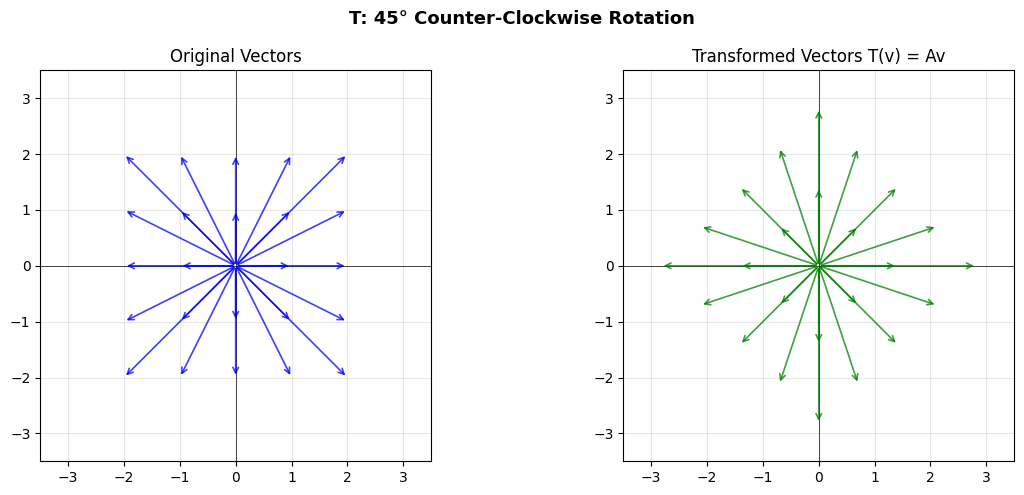

In [49]:
# ---------------------------------------------------------
# PROBLEM 2B: VISUALIZE THE LINEAR TRANSFORMATION
# ---------------------------------------------------------

def plot_linear_transformation(A: np.ndarray, title: str = "Linear Transformation") -> None:
    """
    Visualize a 2x2 linear transformation on a grid of sample vectors.

    Displays two side-by-side subplots: the original vector space (left)
    and the same vectors after applying the transformation matrix A (right).

    Parameters
    ----------
    A : np.ndarray
        2x2 transformation matrix.
    title : str, optional
        Overall figure title.
    """
    grid = np.linspace(-2, 2, 5)
    xx, yy = np.meshgrid(grid, grid)
    vectors = list(zip(xx.ravel(), yy.ravel()))

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    configs = [
        (False, "Original Vectors", "blue"),
        (True,  "Transformed Vectors T(v) = Av", "green"),
    ]

    for ax, (transform, label, color) in zip(axes, configs):
        for xi, yi in vectors:
            v = np.array([xi, yi])
            endpoint = A @ v if transform else v
            ax.annotate(
                "",
                xy=(endpoint[0], endpoint[1]),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color=color, lw=1.2, alpha=0.75),
            )
        ax.set_xlim(-3.5, 3.5)
        ax.set_ylim(-3.5, 3.5)
        ax.axhline(0, color="black", linewidth=0.5)
        ax.axvline(0, color="black", linewidth=0.5)
        ax.set_title(label, fontsize=12)
        ax.grid(True, alpha=0.3)
        ax.set_aspect("equal")

    plt.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


plot_linear_transformation(A_rot, title="T: 45° Counter-Clockwise Rotation")

## **Problem 2c**

Describe geometrically how $T$ transforms vectors in general.

**Answer**: The matrix $A$ is a **45° counter-clockwise rotation** matrix. It rotates every vector in $\mathbb{R}^2$ by $45°$ around the origin while preserving its length (magnitude). Because $A$ is orthogonal ($A^T A = I$) with determinant $= 1$, there is no stretching, squishing, or reflection — purely a rigid rotation. Any vector that starts at angle $\theta$ from the positive $x$-axis will land at angle $\theta + 45°$ after the transformation.

# **Problem 3: Finding Eigenvalues and Eigenvectors**

Let $A$ be the matrix given below.

$$A = \begin{bmatrix} 4 & 0 & 1 \\ -1 & -6 & -2 \\ 5 & 0 & 0 \end{bmatrix}$$

In [50]:
# ---------------------------------------------------------
# HELPER: check_eigenvector
# ---------------------------------------------------------

def check_eigenvector(
    A: np.ndarray,
    v: np.ndarray,
    tol: float = 1e-8,
) -> tuple[bool, float | None]:
    """
    Determine whether a vector is an eigenvector of a matrix.

    A vector v is an eigenvector of A if Av = λv for some scalar λ.
    This is verified by computing Av and checking whether the result
    is proportional to v (i.e., all ratios Av[i]/v[i] are equal).

    Parameters
    ----------
    A : np.ndarray
        Square matrix to test against.
    v : np.ndarray
        Candidate eigenvector.
    tol : float, optional
        Numerical tolerance for floating-point comparison (default 1e-8).

    Returns
    -------
    tuple[bool, float | None]
        (True, eigenvalue) if v is an eigenvector of A, else (False, None).
    """
    Av = A @ v
    nonzero = np.where(np.abs(v) > tol)[0]
    if len(nonzero) == 0:
        return False, None          # zero vector is not an eigenvector
    lam = Av[nonzero[0]] / v[nonzero[0]]
    if np.allclose(Av, lam * v, atol=tol):
        return True, float(lam)
    return False, None


# Define matrix A for all of Problem 3
A_eig = np.array([
    [ 4,  0,  1],
    [-1, -6, -2],
    [ 5,  0,  0]
])

print("Matrix A:")
print(A_eig)

Matrix A:
[[ 4  0  1]
 [-1 -6 -2]
 [ 5  0  0]]


## **Problem 3a**

Is the vector $[1, 2, 3]^T$ an eigenvector of $A$? Verify with Python.

In [51]:
# ---------------------------------------------------------
# PROBLEM 3A: IS [1, 2, 3] AN EIGENVECTOR OF A?
# ---------------------------------------------------------
# If v is an eigenvector, then A @ v = λv for some scalar λ.
# We check by computing A @ v and comparing element-wise ratios.

v1 = np.array([1, 2, 3])
Av1 = A_eig @ v1

print(f"v              = {v1}")
print(f"A @ v          = {Av1}")
print(f"Ratios Av[i]/v[i]: {Av1 / v1}  (must all be equal for eigenvector)")

is_eig, lam = check_eigenvector(A_eig, v1)
print(f"\nIs eigenvector? {is_eig}")

v              = [1 2 3]
A @ v          = [  7 -19   5]
Ratios Av[i]/v[i]: [ 7.         -9.5         1.66666667]  (must all be equal for eigenvector)

Is eigenvector? False


**Answer**: $[1, 2, 3]^T$ is **not** an eigenvector of $A$.  Computing $Av = [7, -19, 5]^T$ and checking the ratios $Av_i / v_i$ gives $7/1 = 7.0$, $-19/2 = -9.5$, $5/3 \approx 1.67$ — the values are not equal, so $Av \neq \lambda v$ for any scalar $\lambda$.

## **Problem 3b**

Is the vector $[0, 1, 0]^T$ an eigenvector of $A$? Verify with Python.

In [52]:
# ---------------------------------------------------------
# PROBLEM 3B: IS [0, 1, 0] AN EIGENVECTOR OF A?
# ---------------------------------------------------------
# The second component is nonzero (1), so we can compute
# the candidate eigenvalue as (A @ v)[1] / v[1].

v2 = np.array([0, 1, 0])
Av2 = A_eig @ v2

print(f"v      = {v2}")
print(f"A @ v  = {Av2}")

is_eig, lam = check_eigenvector(A_eig, v2)
print(f"\nIs eigenvector? {is_eig}")
if is_eig:
    print(f"Eigenvalue λ  = {lam}")
    print(f"Verification: {lam} × {v2} = {lam * v2}")

v      = [0 1 0]
A @ v  = [ 0 -6  0]

Is eigenvector? True
Eigenvalue λ  = -6.0
Verification: -6.0 × [0 1 0] = [-0. -6. -0.]


**Answer**: $[0, 1, 0]^T$ **is** an eigenvector of $A$ with eigenvalue $\lambda = -6$.  Computing $Av = [0, -6, 0]^T = -6 \cdot [0, 1, 0]^T$ confirms this directly.

## **Problem 3c**

Use Python to find **all** eigenvalues and eigenvectors of $A$.

In [53]:
# ---------------------------------------------------------
# PROBLEM 3C: FIND ALL EIGENVALUES AND EIGENVECTORS
# ---------------------------------------------------------
# numpy.linalg.eig() returns:
#   eigenvalues  — 1-D array of eigenvalues
#   eigenvectors — columns of this matrix are the eigenvectors

eigenvalues, eigenvectors = eig(A_eig)

print("Eigenvalues:")
for i, val in enumerate(eigenvalues, 1):
    print(f"  λ{i} = {val:.6f}")

print("\nEigenvectors (each column is one eigenvector):")
for i in range(eigenvectors.shape[1]):
    vec = eigenvectors[:, i]
    print(f"  v{i+1} = {np.round(vec, 6)}")

# Verify every eigenvalue-eigenvector pair: A @ v should equal λ * v
print("\nVerification — A @ v = λv for each pair:")
for i in range(len(eigenvalues)):
    v   = eigenvectors[:, i]
    lhs = A_eig @ v
    rhs = eigenvalues[i] * v
    print(f"  Pair {i+1}: allclose = {np.allclose(lhs, rhs)}")

Eigenvalues:
  λ1 = -6.000000
  λ2 = 5.000000
  λ3 = -1.000000

Eigenvectors (each column is one eigenvector):
  v1 = [0. 1. 0.]
  v2 = [ 0.694314 -0.189358  0.694314]
  v3 = [-0.184932 -0.332877  0.924658]

Verification — A @ v = λv for each pair:
  Pair 1: allclose = True
  Pair 2: allclose = True
  Pair 3: allclose = True


**Answer**: `numpy.linalg.eig()` returns three eigenvalue-eigenvector pairs.  One eigenvalue is $\lambda = -6$, consistent with the result from Problem 3b.  Verification confirms that $A \cdot v_i = \lambda_i \cdot v_i$ holds for all three pairs.

# **Problem 4: Principal Component Analysis**

For this exercise we use the dataset **video_game_data.csv**, which contains four columns: game name, critic score, user score, and total sales.

*(Source: modified version of https://www.kaggle.com/ashaheedq/video-games-sales-2019)*

In [54]:
# ---------------------------------------------------------
# LOAD DATA: video_game_data.csv
# ---------------------------------------------------------
url = (
    "https://raw.githubusercontent.com/dtavizondykstra/BU_Datasets/refs/heads/main/DSC320_MathForDataScience/wk8_video_game_data.csv"
)
df = pd.read_csv(url)

print(f"Shape   : {df.shape}")
print(f"Columns : {list(df.columns)}")
print(f"\nMissing values per column:\n{df.isnull().sum()}")
df.head()

Shape   : (57, 4)
Columns : ['name', 'critic_score', 'user_score', 'total_shipped']

Missing values per column:
name             0
critic_score     0
user_score       0
total_shipped    0
dtype: int64


,name,critic_score,user_score,total_shipped
0,Mario Kart Wii,8.2,9.1,37.14
1,Wii Sports Resort,8.0,8.8,33.09
2,New Super Mario Bros.,9.1,8.1,30.80
3,New Super Mario Bros. Wii,8.6,9.2,30.22
4,Mario Kart DS,9.1,9.4,23.60


## **Problem 4a**

Make a scatterplot of the user scores versus critic scores.

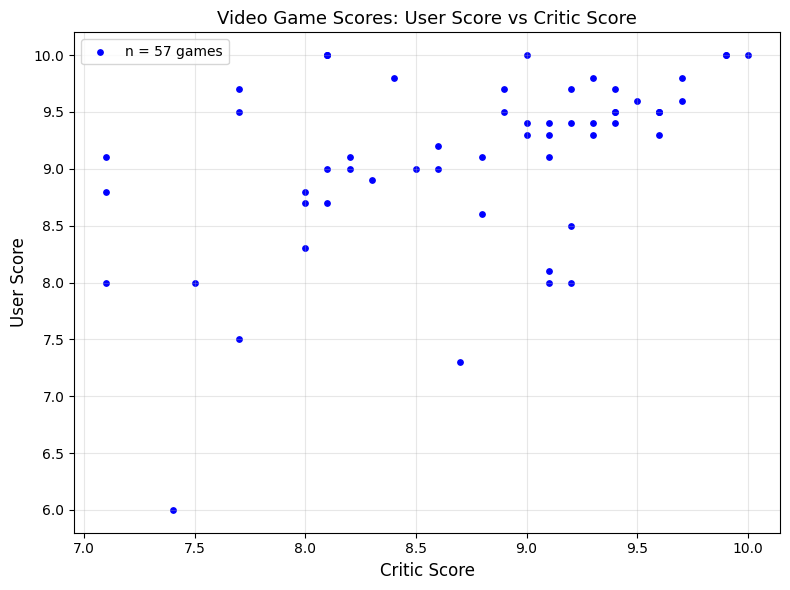


Critic Score — mean: 8.75, std: 0.77
User Score   — mean: 9.12, std: 0.78
Correlation  : 0.4587


In [55]:
# ---------------------------------------------------------
# PROBLEM 4A: SCATTERPLOT — USER SCORE vs CRITIC SCORE
# ---------------------------------------------------------
# Drop rows where either score is missing before plotting.

df_scores = df[["critic_score", "user_score"]].dropna()

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    df_scores["critic_score"],
    df_scores["user_score"],
    s=15,
    color="blue",
    label=f"n = {len(df_scores):,} games",
)
ax.set_xlabel("Critic Score", fontsize=12)
ax.set_ylabel("User Score",   fontsize=12)
ax.set_title("Video Game Scores: User Score vs Critic Score", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nCritic Score — mean: {df_scores['critic_score'].mean():.2f}, "
      f"std: {df_scores['critic_score'].std():.2f}")
print(f"User Score   — mean: {df_scores['user_score'].mean():.2f}, "
      f"std: {df_scores['user_score'].std():.2f}")
print(f"Correlation  : {df_scores['critic_score'].corr(df_scores['user_score']):.4f}")

## **Problem 4b**

On your scatterplot from part (a), sketch the approximate directions of the first and second principal components.

Explained variance ratio:
  PC1: 0.7293  (72.9%)
  PC2: 0.2707  (27.1%)


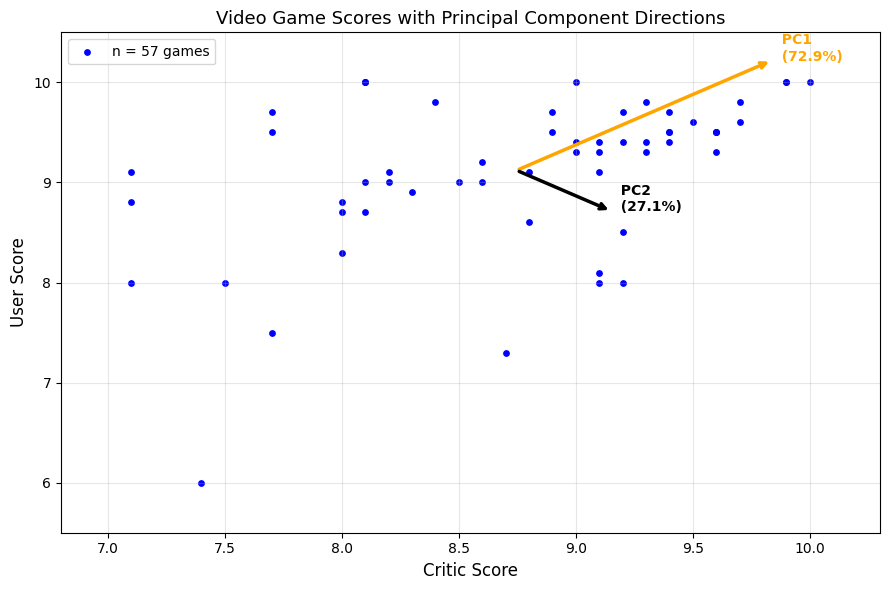

In [56]:
# ---------------------------------------------------------
# PROBLEM 4B: PCA — PRINCIPAL COMPONENT DIRECTIONS
# ---------------------------------------------------------

def plot_pca_on_scatter(
    ax: plt.Axes,
    X_original: np.ndarray,
    pca: PCA,
    scaler: StandardScaler,
    scale: float = 2.0,
) -> None:
    """
    Overlay principal component direction arrows on an existing scatterplot.

    Arrows originate from the data centroid and point in the direction
    of each principal component, scaled by explained variance for clarity.
    Component directions are inverse-transformed from standardized space
    back into the original feature space before plotting.

    Parameters
    ----------
    ax : plt.Axes
        Matplotlib axes to draw the arrows on.
    X_original : np.ndarray
        Original (unscaled) feature matrix, shape (n_samples, 2).
    pca : PCA
        Fitted sklearn PCA instance.
    scaler : StandardScaler
        Fitted StandardScaler used to preprocess X_original.
    scale : float, optional
        Multiplier controlling arrow length (default 2.0).
    """
    mean   = X_original.mean(axis=0)
    colors = ["orange", "black"]
    labels = ["PC1", "PC2"]

    for component, color, label, var_ratio in zip(
        pca.components_, colors, labels, pca.explained_variance_ratio_
    ):
        # project component direction back into original feature scale
        direction = component * scaler.scale_
        # scale arrows relative to actual data range so they stay within the plot
        data_span = np.ptp(X_original, axis=0).mean()
        length    = scale * var_ratio * data_span * 0.4

        ax.annotate(
            "",
            xy=(mean[0] + length * direction[0], mean[1] + length * direction[1]),
            xytext=(mean[0], mean[1]),
            arrowprops=dict(arrowstyle="->", color=color, lw=2.5),
        )
        ax.text(
            mean[0] + length * direction[0],
            mean[1] + length * direction[1],
            f"  {label}\n  ({var_ratio:.1%})",
            color=color, fontsize=10, fontweight="bold",
        )


X = df_scores[["critic_score", "user_score"]].values

# standardize before PCA — keeps both features on equal footing
scaler_pca = StandardScaler()
X_scaled   = scaler_pca.fit_transform(X)

pca = PCA(n_components=2)
pca.fit(X_scaled)

print("Explained variance ratio:")
for i, ratio in enumerate(pca.explained_variance_ratio_, 1):
    print(f"  PC{i}: {ratio:.4f}  ({ratio:.1%})")

# scatterplot with principal component arrows overlaid
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(
    df_scores["critic_score"],
    df_scores["user_score"], 
    s=15, 
    color="blue", 
    label=f"n = {len(df_scores):,} games",
)
plot_pca_on_scatter(ax, X, pca, scaler_pca, scale=2.0)

ax.set_xlabel("Critic Score", fontsize=12)
ax.set_ylabel("User Score",   fontsize=12)
ax.set_title("Video Game Scores with Principal Component Directions", fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim(df_scores["critic_score"].min() - 0.3, df_scores["critic_score"].max() + 0.3)
ax.set_ylim(df_scores["user_score"].min() - 0.5, df_scores["user_score"].max() + 0.5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Answer**: After standardizing the data, PCA identifies two orthogonal directions that capture the most variance in the critic-score / user-score space.

- **PC1** (orange arrow) points along the axis of maximum variance — roughly the positive diagonal,   indicating that critic scores and user scores tend to move together (positive correlation).   It captures the majority of the total variance.
- **PC2** (black arrow) is perpendicular to PC1 and captures the remaining variance —   roughly representing the axis where the two scores diverge from each other.

Together the two components account for 100% of the variance in this two-feature space, since PCA on 2 dimensions always yields exactly 2 components.